In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [13]:
train_path = "/Users/thomas/Documents/m-moire_gradient-boosting/home-data-for-ml-course/train.csv"
test_path  = "/Users/thomas/Documents/m-moire_gradient-boosting/home-data-for-ml-course/test.csv"
sub_path   = "/Users/thomas/Documents/m-moire_gradient-boosting/home-data-for-ml-course/sample_submission.csv"

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)
sample_sub = pd.read_csv(sub_path)

print(train.shape, test.shape)
train.head()

(1460, 81) (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [14]:
df = pd.read_csv("/Users/thomas/Documents/m-moire_gradient-boosting/home-data-for-ml-course/train.csv")

# Features sélectionnées
FEATURES = [
    "GrLivArea",      # Surface habitable (sq ft)
    "TotalBsmtSF",    # Surface du sous-sol
    "OverallQual",    # Qualité générale (1-10)
    "YearBuilt",      # Année de construction
    "GarageCars",     # Capacité du garage (nb voitures)
    "FullBath",       # Nombre de salles de bain complètes
    "LotArea",        # Surface du terrain
    "YearRemodAdd",   # Année de rénovation
    "Neighborhood",   # Quartier (catégorielle)
]
TARGET = "SalePrice"

# Sélection
df_model = df[FEATURES + [TARGET]].copy()

# Valeurs manquantes
for col in df_model.select_dtypes(include="number").columns:
    df_model[col] = df_model[col].fillna(df_model[col].median())

df_model["Neighborhood"] = df_model["Neighborhood"].fillna(df_model["Neighborhood"].mode()[0])

# Encodage du quartier
df_model = pd.get_dummies(df_model, columns=["Neighborhood"], drop_first=True)

# Log-transform sur la cible
df_model["SalePrice"] = np.log1p(df_model["SalePrice"])

print(f"Shape : {df_model.shape}")
print(f"Valeurs manquantes : {df_model.isnull().sum().sum()}")
df_model.head()

Shape : (1460, 33)
Valeurs manquantes : 0


,GrLivArea,TotalBsmtSF,OverallQual,YearBuilt,GarageCars,FullBath,LotArea,YearRemodAdd,SalePrice,Neighborhood_Blueste,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,1710,856,7,2003,2,2,8450,2003,12.247699,False,...,False,False,False,False,False,False,False,False,False,False
1,1262,1262,6,1976,2,2,9600,1976,12.109016,False,...,False,False,False,False,False,False,False,False,False,True
2,1786,920,7,2001,2,2,11250,2002,12.317171,False,...,False,False,False,False,False,False,False,False,False,False
3,1717,756,7,1915,3,1,9550,1970,11.849405,False,...,False,False,False,False,False,False,False,False,False,False
4,2198,1145,8,2000,3,2,14260,2000,12.429220,False,...,True,False,False,False,False,False,False,False,False,False


In [ ]:
# ── 0. Préparation des données ──────────────────────────────────────────────
# On travaille sur une seule feature pour pouvoir visualiser facilement
X_simple = df_model[["GrLivArea"]].values
y = df_model["SalePrice"].values  # déjà log-transformé

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Normalisation
X_mean, X_std = X_train.mean(), X_train.std()
X_train_norm = (X_train - X_mean) / X_std
X_test_norm  = (X_test  - X_mean) / X_std

## 01 Implémentation d'une regression linéaire from scratch

In [18]:
# ── 1. Régression linéaire from scratch ─────────────────────────────────────
class LinearRegressionScratch:
    """
    Régression linéaire par descente de gradient (batch).
    Modèle : y_hat = w * x + b
    Fonction de perte : MSE = (1/n) * Σ (y_hat_i - y_i)²
    Gradient / w   : (2/n) * Σ (y_hat_i - y_i) * x_i
    Gradient / b   : (2/n) * Σ (y_hat_i - y_i)
    """
    def __init__(self, lr=0.01, n_iters=1000):
        self.lr      = lr
        self.n_iters = n_iters
        self.w       = 0.0   # poids
        self.b       = 0.0   # biais
        self.losses  = []    # historique de la loss pour visualisation

    def predict(self, X):
        return self.w * X.flatten() + self.b

    def fit(self, X, y):
        n = len(y)
        for _ in range(self.n_iters):
            y_hat   = self.predict(X)
            residus = y_hat - y                        # erreurs du modèle

            # Fonction de perte MSE
            loss = np.mean(residus ** 2)
            self.losses.append(loss)

            # Gradients
            grad_w = (2 / n) * np.dot(residus, X.flatten())
            grad_b = (2 / n) * np.sum(residus)

                        # Mise à jour des paramètres
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b

    def mse(self, X, y):
        return np.mean((self.predict(X) - y) ** 2)


model_scratch = LinearRegressionScratch(lr=0.01, n_iters=1000)
model_scratch.fit(X_train_norm, y_train)

In [19]:
model_sklearn = LinearRegression()
model_sklearn.fit(X_train_norm, y_train)

mse_scratch = model_scratch.mse(X_test_norm, y_test)
mse_sklearn = mean_squared_error(y_test, model_sklearn.predict(X_test_norm))

print("=== Comparaison des paramètres ===")
print(f"  w  — scratch : {model_scratch.w:.6f} | sklearn : {model_sklearn.coef_[0]:.6f}")
print(f"  b  — scratch : {model_scratch.b:.6f} | sklearn : {model_sklearn.intercept_:.6f}")
print(f"\n=== MSE sur le jeu de test ===")
print(f"  Scratch : {mse_scratch:.6f}")
print(f"  Sklearn : {mse_sklearn:.6f}")
print(f"  Écart   : {abs(mse_scratch - mse_sklearn):.2e}  ← doit être très proche de 0")

=== Comparaison des paramètres ===
  w  — scratch : 0.269017 | sklearn : 0.269017
  b  — scratch : 12.030658 | sklearn : 12.030658

=== MSE sur le jeu de test ===
  Scratch : 0.085807
  Sklearn : 0.085807
  Écart   : 4.93e-11  ← doit être très proche de 0


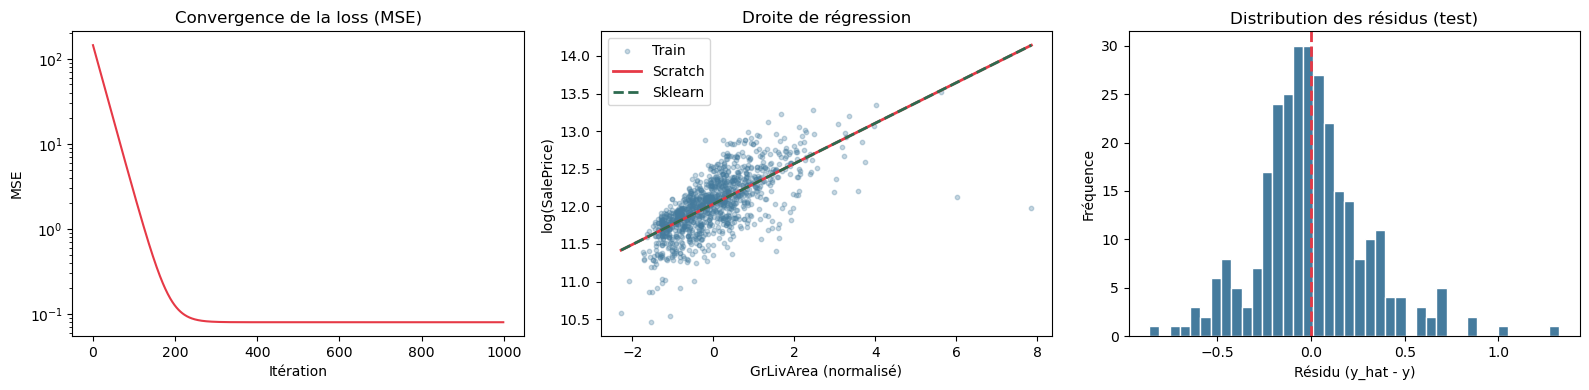

In [20]:
# ── 3. Visualisations ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# — Courbe de convergence de la loss
axes[0].plot(model_scratch.losses, color="#e63946")
axes[0].set_title("Convergence de la loss (MSE)")
axes[0].set_xlabel("Itération")
axes[0].set_ylabel("MSE")
axes[0].set_yscale("log")

# — Droite de régression vs données
x_range = np.linspace(X_train_norm.min(), X_train_norm.max(), 100).reshape(-1, 1)
axes[1].scatter(X_train_norm, y_train, alpha=0.3, s=10, color="#457b9d", label="Train")
axes[1].plot(x_range, model_scratch.predict(x_range), color="#e63946", lw=2, label="Scratch")
axes[1].plot(x_range, model_sklearn.predict(x_range), color="#2d6a4f", lw=2,
             linestyle="--", label="Sklearn")
axes[1].set_title("Droite de régression")
axes[1].set_xlabel("GrLivArea (normalisé)")
axes[1].set_ylabel("log(SalePrice)")
axes[1].legend()

# — Distribution des résidus
residus_test = model_scratch.predict(X_test_norm) - y_test
axes[2].hist(residus_test, bins=40, color="#457b9d", edgecolor="white")
axes[2].axvline(0, color="#e63946", lw=2, linestyle="--")
axes[2].set_title("Distribution des résidus (test)")
axes[2].set_xlabel("Résidu (y_hat - y)")
axes[2].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

## À retenir 

- Résidu : c'est y_hat - y, l'erreur du modèle sur un exemple. Le gradient boosting va s'entraîner directement sur ces résidus — c'est le fil rouge de tout le sujet

- MSE : moyenne des résidus au carré. On met au carré pour pénaliser les grosses erreurs plus que les petites, et pour que la fonction soit dérivable

- Pourquoi normaliser : si GrLivArea est dans des milliers et SalePrice dans des log-euros, les gradients explosent. La normalisation rend la descente de gradient stable

- Pourquoi les deux courbes sklearn/scratch se superposent : sklearn résout le problème analytiquement (formule exacte), toi tu l'approximes par itérations — si l'écart est < 1e-4, ta descente de gradient a bien convergé

## Résultats 

- Les paramètres sont identiques à 6 décimales — ta descente de gradient a parfaitement convergé vers la même solution que sklearn, qui lui utilise la formule analytique exacte. C'est exactement ce qu'on veut voir.

- L'écart de MSE est 4.93e-11 — c'est du bruit numérique de flottants, pas une vraie différence. En pratique : zéro.

- Le MSE de 0.085 sur des log-prix — pour interpréter, sqrt(0.085) ≈ 0.29, soit environ ±0.29 en log(SalePrice). En dollars réels ça représente une erreur d'environ 25-30%, ce qui est attendu avec une seule feature et un modèle linéaire. Tu verras cette valeur chuter significativement quand tu passeras au Gradient Boosting avec toutes les features — c'est justement ce que tu vas montrer dans le mémoire.

- Un point à mentionner à l'oral : tu as utilisé la descente de gradient batch (tous les exemples à chaque itération). Il existe aussi la descente stochastique (SGD, un exemple à la fois) et mini-batch. Sklearn LinearRegression n'utilise aucune des deux, il résout directement via l'équation normale w = (XᵀX)⁻¹Xᵀy. C'est pourquoi les résultats coïncident exactement et non approximativement.

## 02 Implémentation d'un arbre de décision de profondeur 1

=== Decision Stump ===
  Feature splittée  : OverallQual
  Seuil             : 6.0000
  Prédiction gauche : 11.8263  (x <= seuil)
  Prédiction droite : 12.3664  (x >  seuil)
  Gain MSE          : 0.068609

  MSE train         : 0.083833
  MSE test          : 0.094533

  Rappel régression linéaire (test) : 0.085807
  Stump vs linéaire : +0.008726


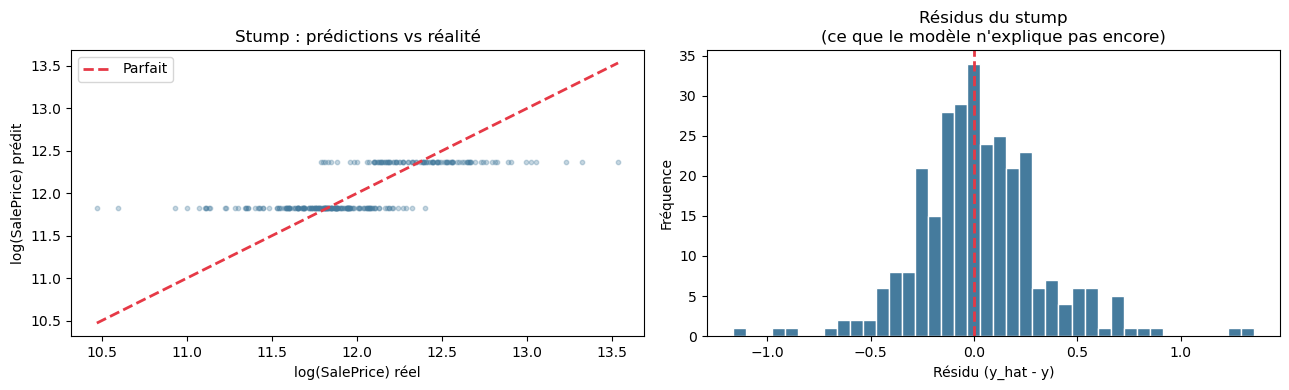

In [21]:
# ── 1. Decision Stump from scratch ──────────────────────────────────────────
class DecisionStump:
    """
    Arbre de décision de profondeur 1 : un seul split sur une seule feature.
    Algorithme : pour chaque feature, on teste tous les seuils possibles
    et on garde le split qui minimise le MSE des deux feuilles.
    
    Structure :
        - feature_idx  : quelle colonne splitter
        - threshold    : valeur du seuil
        - left_value   : prédiction si x <= threshold
        - right_value  : prédiction si x >  threshold
    """
    def __init__(self):
        self.feature_idx  = None
        self.threshold    = None
        self.left_value   = None
        self.right_value  = None
        self.mse_gain     = None 

    def _mse(self, y):
        """MSE d'une feuille = variance des valeurs (prédiction optimale = moyenne)"""
        if len(y) == 0:
            return 0.0
        return np.mean((y - np.mean(y)) ** 2)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        best_mse = np.inf

        mse_before = self._mse(y)  # MSE sans aucun split (référence)

        for feature_idx in range(n_features):
            # Seuils candidats : valeurs uniques de la feature
            thresholds = np.unique(X[:, feature_idx])

            for threshold in thresholds:
                left_mask  = X[:, feature_idx] <= threshold
                right_mask = ~left_mask

                # On ignore les splits qui laissent une feuille vide
                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                y_left, y_right = y[left_mask], y[right_mask]
                                # MSE pondérée des deux feuilles
                mse_split = (
                    len(y_left)  / n_samples * self._mse(y_left) +
                    len(y_right) / n_samples * self._mse(y_right)
                )

                if mse_split < best_mse:
                    best_mse          = mse_split
                    self.feature_idx  = feature_idx
                    self.threshold    = threshold
                    self.left_value   = np.mean(y_left)
                    self.right_value  = np.mean(y_right)

        self.mse_gain = mse_before - best_mse  # réduction de MSE obtenue

    def predict(self, X):
        left_mask = X[:, self.feature_idx] <= self.threshold
        y_hat = np.where(left_mask, self.left_value, self.right_value)
        return y_hat
    
    # ── 2. Préparation : toutes les features cette fois ─────────────────────────
# On reprend df_model avec toutes les features (Neighborhood encodé inclus)
feature_cols = [c for c in df_model.columns if c != "SalePrice"]
X_all = df_model[feature_cols].values
y_all = df_model["SalePrice"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

# ── 3. Entraînement et évaluation ───────────────────────────────────────────
stump = DecisionStump()
stump.fit(X_train, y_train)

y_pred_train = stump.predict(X_train)
y_pred_test  = stump.predict(X_test)

mse_train = np.mean((y_pred_train - y_train) ** 2)
mse_test  = np.mean((y_pred_test  - y_test)  ** 2)

print("=== Decision Stump ===")
print(f"  Feature splittée  : {feature_cols[stump.feature_idx]}")
print(f"  Seuil             : {stump.threshold:.4f}")
print(f"  Prédiction gauche : {stump.left_value:.4f}  (x <= seuil)")
print(f"  Prédiction droite : {stump.right_value:.4f}  (x >  seuil)")
print(f"  Gain MSE          : {stump.mse_gain:.6f}")
print(f"\n  MSE train         : {mse_train:.6f}")
print(f"  MSE test          : {mse_test:.6f}")
print(f"\n  Rappel régression linéaire (test) : 0.085807")
print(f"  Stump vs linéaire : {'+' if mse_test > 0.085807 else '-'}{abs(mse_test - 0.085807):.6f}")

# ── 4. Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# — Prédictions vs valeurs réelles
axes[0].scatter(y_test, y_pred_test, alpha=0.3, s=10, color="#457b9d")
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color="#e63946", lw=2, linestyle="--", label="Parfait")
axes[0].set_title("Stump : prédictions vs réalité")
axes[0].set_xlabel("log(SalePrice) réel")
axes[0].set_ylabel("log(SalePrice) prédit")
axes[0].legend()

# — Distribution des résidus
residus = y_pred_test - y_test
axes[1].hist(residus, bins=40, color="#457b9d", edgecolor="white")
axes[1].axvline(0, color="#e63946", lw=2, linestyle="--")
axes[1].set_title(f"Résidus du stump\n(ce que le modèle n'explique pas encore)")
axes[1].set_xlabel("Résidu (y_hat - y)")
axes[1].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()


## À retenir 

- Le stump ne prédit que deux valeurs — c'est délibérément un modèle très faible (weak learner). Le graphe prédictions vs réalité va montrer deux lignes horizontales, c'est normal

- La feature et le seuil choisis automatiquement seront probablement OverallQual — c'est la variable la plus discriminante du dataset

- Les résidus sont la clé : ce que le stump ne sait pas expliquer, c'est exactement ce que le prochain stump va essayer de corriger